# Data Quality Assessment

Quality control checks for the ReKIS precipitation dataset:
1. Dataset overview & basic statistics
2. Missing / negative values
3. Duplicate records (root cause: `Stationsliste.txt`)
4. Co-located stations & merging strategy
5. Temporal coverage (active stations per year)
6. Station map

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer
from scipy.spatial import cKDTree

ROOT = Path.cwd().parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.datasets.protocols import PredictionGrid
from thesis.data.dem import DEMSource

In [2]:
import os
print(os.listdir())

['.DS_Store', 'ctufit-thesis.bbl', 'uv.lock', 'vastai', '.pytest_cache', 'papers', 'ismaktam-assignment.pdf', 'images', 'Dockerfile', 'pyproject.toml', 'tests', '.claude', 'thesis_ismaktam', 'vastai.pub', 'pdfa.xmpi', 'ctufit-thesis.fdb_latexmk', 'README.md', 'results', '.dockerignore', '.gitignore', '.env', '.venv', 'scripts', 'text', '.git', 'ctufit-thesis.fls', '.vscode', 'ctufit-thesis.log', 'data', 'outputs', 'notebooks', 'CLAUDE.md', 'src', 'tdp']


In [3]:
cfg = Config()
registry = DataRegistry.from_config(cfg)

data = registry.stations.load(date_start="2023-12-30", date_end=cfg.date_end,  exclude_holdout=False)
stations = registry.stations.load_stations()

print(f"Period: {cfg.date_start} — {cfg.date_end}")
print(f"Records: {len(data):,}")
print(f"Stations: {data['station_id'].nunique()}")
data.head()

Period: 1961-01-01 — 2023-12-31
Records: 4,916
Stations: 2458


,station_id,date,lon,lat,elevation_m,precip_mm
0,CZ_H1LBOU01,2023-12-30,15.545300,50.770000,1300.0,7.7
1,CZ_H1VITK01,2023-12-30,15.550000,50.750000,1410.0,6.1
2,CZ_H3BYCH01,2023-12-30,15.250000,50.083300,214.0,0.0
3,CZ_H3CHLM01,2023-12-30,15.462251,50.137135,213.0,0.0
4,CZ_H3DYMO01,2023-12-30,15.198100,50.248100,208.0,2.8


## 1. Basic Quality Checks

In [ ]:
n_total = len(data)
n_nan = data["precip_mm"].isna().sum()
n_neg = (data["precip_mm"] < 0).sum()
n_dup = data.duplicated(subset=["station_id", "date"]).sum()

print(f"{'Total records':<30}: {n_total:>12,}")
print(f"{'NaN precip_mm':<30}: {n_nan:>12,}")
print(f"{'Negative values':<30}: {n_neg:>12,}")
print(f"{'Duplicate (station, date)':<30}: {n_dup:>12,}")

## 2. Co-located Stations

Stations within 100 m of each other cause near-singular kriging matrices.
The loader merges co-located gauges by averaging their values.

In [ ]:
transformer = Transformer.from_crs("EPSG:4326", cfg.study_area.target_crs, always_xy=True)
sc = data[["station_id", "lon", "lat"]].drop_duplicates("station_id").copy()
x, y = transformer.transform(sc["lon"].values, sc["lat"].values)
sc = sc.assign(x_m=x, y_m=y)

tree = cKDTree(sc[["x_m", "y_m"]].values)

for radius, label in [(100, "100 m"), (1000, "1 km")]:
    pairs = tree.query_pairs(r=radius)
    n_stations = len({i for pair in pairs for i in pair})
    print(f"Within {label:>5}: {n_stations} stations ({len(pairs)} pairs)")

# Show exact duplicates
exact_dup = sc.duplicated(subset=["lon", "lat"], keep=False)
if exact_dup.sum() > 0:
    print(f"\nExact same coordinates ({exact_dup.sum()} stations):")
    print(sc[exact_dup].sort_values(["lon", "lat"]).to_string(index=False))

## 3. Root Cause: Duplicate IDs in Stationsliste.txt

The raw `Stationsliste.txt` contains 5029 rows for 4986 unique station IDs.
38 IDs appear 2–3 times (identical coordinates), causing row multiplication during the merge.
The loader deduplicates with `drop_duplicates(subset='station_id', keep='first')`.

In [ ]:
rekis_dir = Path(cfg.paths.root) / "rekis"
stl = pd.read_csv(rekis_dir / "Stationsliste.txt", sep=",")

dup_ids = stl[stl["Stat_ID"].duplicated(keep=False)].sort_values("Stat_ID")
print(f"Stationsliste.txt: {len(stl)} rows, {stl['Stat_ID'].nunique()} unique IDs")
print(f"Duplicated IDs: {dup_ids['Stat_ID'].nunique()} (affecting {len(dup_ids)} rows)")
print()
print("Occurrences per duplicated ID:")
print(dup_ids.groupby("Stat_ID").size().value_counts().sort_index().to_string())

In [ ]:
# Verify: all duplicates have identical coordinates
for sid in dup_ids["Stat_ID"].unique()[:10]:
    rows = stl[stl["Stat_ID"] == sid]
    coords_same = rows[["Laenge", "Breite", "Hoehe"]].drop_duplicates().shape[0] == 1
    print(f"  {sid}: {len(rows)} entries, coords identical = {coords_same}")

## 4. Temporal Coverage

In [ ]:
df = data.copy()
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

MIN_DAYS = 180

days_per_sy = (
    df.groupby(["year", "station_id"])["precip_mm"]
    .count()
    .reset_index(name="n_days")
)

active = days_per_sy[days_per_sy["n_days"] >= MIN_DAYS]
stations_per_year = active.groupby("year")["station_id"].nunique()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(stations_per_year.index, stations_per_year.values, color="steelblue", width=0.8)
ax.set_xlabel("Year")
ax.set_ylabel(f"Active stations (≥{MIN_DAYS} days)")
ax.set_title("Temporal coverage of the ReKIS network")
ax.set_xlim(stations_per_year.index.min() - 0.5, stations_per_year.index.max() + 0.5)
plt.tight_layout()
plt.show()

print(f"Min: {stations_per_year.min()} ({stations_per_year.idxmin()})")
print(f"Max: {stations_per_year.max()} ({stations_per_year.idxmax()})")
print(f"Mean: {stations_per_year.mean():.0f}")

## 5. Monthly & Elevation Statistics

In [ ]:
df["month"] = df["date"].dt.month

monthly_totals = (
    df.dropna(subset=["precip_mm"])
    .groupby(["station_id", "year", "month"])["precip_mm"]
    .sum()
    .reset_index(name="monthly_mm")
)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

table = monthly_totals.groupby("month")["monthly_mm"].mean()
print("Mean monthly precipitation (mm), averaged across all station-years:")
for m, val in table.items():
    print(f"  {month_names[m-1]:>3}: {val:.1f}")

In [ ]:
def elevation_zone(elev):
    if elev < 250:
        return "Plains (0–250 m)"
    elif elev < 500:
        return "Hills (250–500 m)"
    return "Mountains (500+ m)"

station_meta = df[["station_id", "elevation_m"]].drop_duplicates("station_id").copy()
station_meta["zone"] = station_meta["elevation_m"].apply(elevation_zone)

mt_with_zone = monthly_totals.merge(station_meta[["station_id", "zone", "elevation_m"]], on="station_id")

zone_order = ["Plains (0–250 m)", "Hills (250–500 m)", "Mountains (500+ m)"]
table2 = (
    mt_with_zone.groupby("zone")
    .agg(N_stations=("station_id", "nunique"),
         Mean_elev=("elevation_m", "mean"),
         Mean_mm=("monthly_mm", "mean"))
    .reindex(zone_order)
)
table2["Mean_elev"] = table2["Mean_elev"].round(0).astype(int)
table2["Mean_mm"] = table2["Mean_mm"].round(1)
table2.columns = ["N stations", "Mean elev (m)", "Mean precip (mm/month)"]
print(table2.to_string())

## 6. Station Map

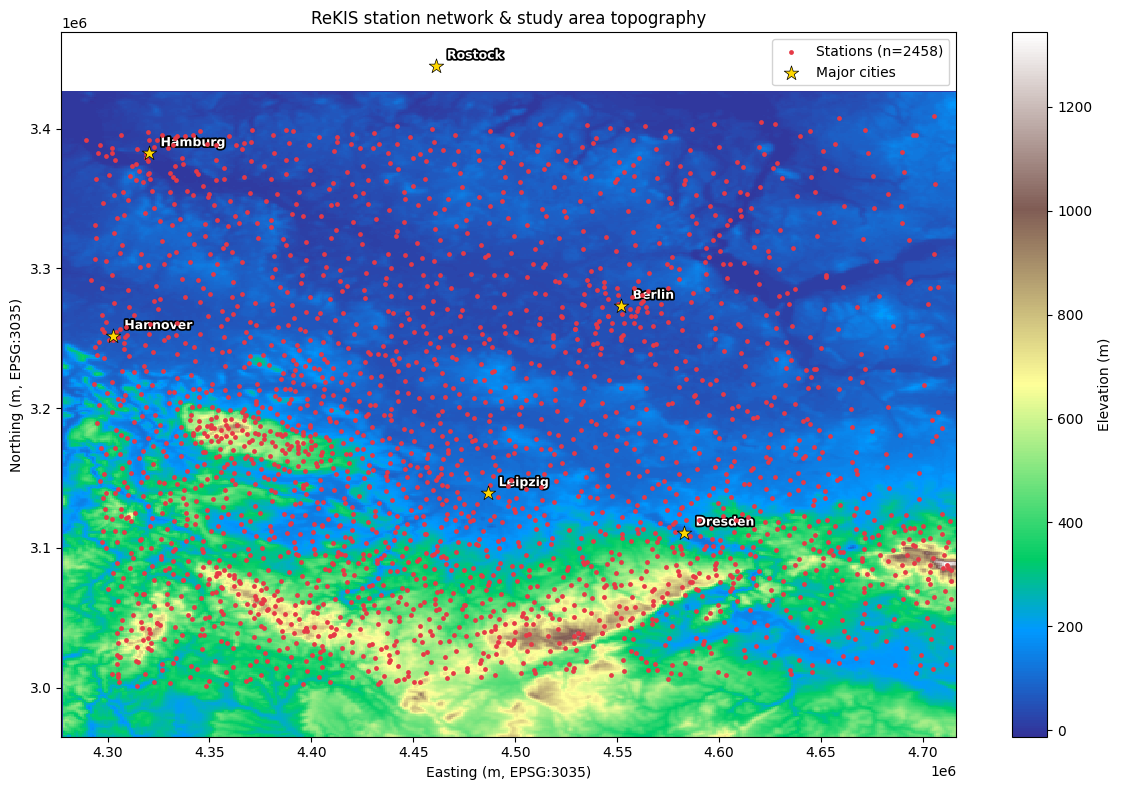

In [4]:
import matplotlib.patheffects as pe

dem = DEMSource(cfg)
grid = PredictionGrid.from_config(cfg, dem=dem)

# Project stations
stations_xy = data[["station_id", "lon", "lat"]].drop_duplicates("station_id")
t = Transformer.from_crs("EPSG:4326", cfg.study_area.target_crs, always_xy=True)
sx, sy = t.transform(stations_xy["lon"].values, stations_xy["lat"].values)

# Cities
cities = {
    "Berlin":   (13.405, 52.520),
    "Hamburg":  (9.993,  53.550),
    "Dresden":  (13.738, 51.050),
    "Leipzig":  (12.374, 51.340),
    "Hannover": (9.732,  52.374),
    "Rostock":  (12.140, 54.092),
}
cx, cy = t.transform([v[0] for v in cities.values()], [v[1] for v in cities.values()])

# DEM grid
H, W = grid.shape
xg = grid.coords_proj[:, 0].reshape(H, W)
yg = grid.coords_proj[:, 1].reshape(H, W)
zg = grid.elevation_m.reshape(H, W)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.pcolormesh(xg, yg, zg, shading="auto", cmap="terrain")
plt.colorbar(im, ax=ax, label="Elevation (m)")

ax.scatter(sx, sy, s=12, c="#e63946", marker="o", zorder=5, linewidths=0,
           label=f"Stations (n={len(stations_xy)})")

ax.scatter(cx, cy, s=120, c="#ffd700", marker="*", zorder=10, linewidths=0.5,
           edgecolors="black", label="Major cities")

for name, xi, yi in zip(cities.keys(), cx, cy):
    ax.annotate(name, (xi, yi), textcoords="offset points", xytext=(8, 5),
                fontsize=9, color="white", fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])

ax.set_xlabel("Easting (m, EPSG:3035)")
ax.set_ylabel("Northing (m, EPSG:3035)")
ax.set_title("ReKIS station network & study area topography")
ax.legend(loc="upper right", framealpha=0.85)
plt.tight_layout()
plt.show()

## Summary

| Check | Result |
|-------|--------|
| Missing values | 0 |
| Negative values | 0 |
| Duplicates after dedup | 0 |
| Co-located (exact) | 8 stations (4 pairs) — merged by loader |
| Root cause | 38 IDs duplicated in `Stationsliste.txt` |
| Fix | `drop_duplicates` + co-located merge in `ReKISSource` |